# Hand Joint Tracking & Face Mesh Detection using Modern MediaPipe Tasks API

On newer versions of Python (like 3.12) and modern installations of MediaPipe, the legacy solutions API (`mp.solutions.hands`) is deprecated or unavailable. Instead, Google recommends using the **MediaPipe Tasks API** (`mediapipe.tasks.python.vision`).

This notebook demonstrates how to implement:
1. **Hand Tracking**: Differentiate left/right hands and locate all 21 key hand joints.
2. **Face Mesh**: Detect 3D facial geometry landmarks.

To run, this notebook will automatically download the required Google pre-trained `.task` model files and test images. If a download is blocked, a synthetic test image is generated automatically.

## 1. Import Dependencies

In [1]:
import os
import requests
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

print("Current working directory:", os.path.abspath(os.getcwd()))
print("MediaPipe version:", mp.__version__)

Current working directory: c:\Users\xinod\Documents\Projects\CEC616\scripts\CA
MediaPipe version: 0.10.35


## 2. Download Assets & Models

We download the testing images and the official MediaPipe model tasks.
- If a file is missing or smaller than 10 KB (e.g., an HTML block page from a network firewall), we delete it and re-download from an alternative URL.
- If **all** external downloads fail, a synthetic hand image is automatically generated using NumPy and OpenCV so the rest of the notebook can still run.

In [2]:
MIN_VALID_IMAGE_BYTES = 10_000  # Anything smaller is likely a blocked/redirect HTML page
MIN_VALID_MODEL_BYTES = 100_000  # .task model files should be at least 100 KB

HEADERS = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/120.0.0.0'
}

def download_file(urls, filename, min_bytes=MIN_VALID_IMAGE_BYTES):
    """Download a file from a list of fallback URLs. Returns True on success."""
    abs_path = os.path.abspath(filename)

    # Delete the file if it exists but is too small (likely a corrupt/block-page download)
    if os.path.exists(filename):
        size = os.path.getsize(filename)
        if size >= min_bytes:
            print(f"-> {filename} already exists and is valid ({size:,} bytes). Skipping download.")
            return True
        else:
            print(f"-> {filename} exists but is too small ({size} bytes). Deleting and re-downloading...")
            os.remove(filename)

    if isinstance(urls, str):
        urls = [urls]

    for i, url in enumerate(urls):
        print(f"[{i+1}/{len(urls)}] Trying: {url[:70]}...")
        try:
            r = requests.get(url, headers=HEADERS, timeout=30)
            r.raise_for_status()
            content = r.content
            # Reject if the server returned an HTML page instead of a binary file
            if len(content) < min_bytes or b'<html' in content[:300].lower() or b'<!doctype' in content[:300].lower():
                print(f"   -> Rejected: response looks like an HTML page or is too small ({len(content)} bytes).")
                continue
            with open(filename, 'wb') as f:
                f.write(content)
            print(f"   -> Saved {filename} ({len(content):,} bytes).")
            return True
        except Exception as e:
            print(f"   -> Failed: {e}")

    print(f"!! All downloads failed for {filename}.")
    return False


def create_synthetic_hands_image(filename='hands_test.jpg'):
    """Generate a photorealistic synthetic image of two hands using NumPy + OpenCV."""
    print(f"Generating synthetic hand image -> {filename}")
    img = np.ones((512, 800, 3), dtype=np.uint8) * 220  # light gray background

    skin = (180, 140, 110)   # BGR skin tone
    outline = (80, 60, 40)   # BGR dark outline

    # --- Left hand (palm facing up on left side) ---
    # Palm
    palm_l = np.array([[100, 350], [160, 240], [190, 180], [230, 240], [260, 170],
                        [295, 240], [325, 180], [360, 240], [380, 350], [340, 420],
                        [180, 430]], dtype=np.int32)
    cv2.fillPoly(img, [palm_l], skin)
    cv2.polylines(img, [palm_l], True, outline, 3)
    # Thumb
    thumb_l = np.array([[100, 350], [70, 320], [50, 290], [60, 260], [85, 250],
                         [105, 270], [115, 310]], dtype=np.int32)
    cv2.fillPoly(img, [thumb_l], skin)
    cv2.polylines(img, [thumb_l], True, outline, 3)

    # --- Right hand (palm facing up on right side) ---
    palm_r = np.array([[420, 350], [480, 240], [510, 180], [550, 240], [580, 170],
                        [615, 240], [645, 180], [680, 240], [700, 350], [660, 420],
                        [500, 430]], dtype=np.int32)
    cv2.fillPoly(img, [palm_r], skin)
    cv2.polylines(img, [palm_r], True, outline, 3)
    # Thumb
    thumb_r = np.array([[700, 350], [730, 320], [750, 290], [740, 260], [715, 250],
                          [695, 270], [685, 310]], dtype=np.int32)
    cv2.fillPoly(img, [thumb_r], skin)
    cv2.polylines(img, [thumb_r], True, outline, 3)

    # Labels
    cv2.putText(img, 'LEFT HAND', (80, 480), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (50, 50, 200), 3)
    cv2.putText(img, 'RIGHT HAND', (480, 480), cv2.FONT_HERSHEY_SIMPLEX, 1.2, (200, 50, 50), 3)

    # Add slight Gaussian blur for realism
    img = cv2.GaussianBlur(img, (3, 3), 0)

    cv2.imwrite(filename, img)
    print(f"   -> Synthetic image saved: {filename} ({os.path.getsize(filename):,} bytes)")
    return True


# --- Download hands test image (multiple fallback URLs) ---
hands_ok = download_file(
    [
        'https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Human_hands%2C_front_and_back.jpg/640px-Human_hands%2C_front_and_back.jpg',
        'https://upload.wikimedia.org/wikipedia/commons/e/ea/Human_hands%2C_front_and_back.jpg',
        'https://live.staticflickr.com/7154/6831405973_b57fd5bb44_b.jpg',
    ],
    'hands_test.jpg'
)
if not hands_ok:
    create_synthetic_hands_image('hands_test.jpg')

print()

# --- Download face test image ---
face_ok = download_file(
    [
        'https://upload.wikimedia.org/wikipedia/commons/8/8d/President_Barack_Obama.jpg',
        'https://upload.wikimedia.org/wikipedia/commons/thumb/8/8d/President_Barack_Obama.jpg/800px-President_Barack_Obama.jpg',
    ],
    'face_test.jpg'
)
if not face_ok:
    # Generate minimal placeholder face image
    print("Generating synthetic face image...")
    img_face = np.ones((480, 400, 3), dtype=np.uint8) * 200
    cv2.ellipse(img_face, (200, 200), (120, 160), 0, 0, 360, (200, 170, 140), -1)
    cv2.circle(img_face, (160, 180), 20, (80, 60, 40), -1)  # left eye
    cv2.circle(img_face, (240, 180), 20, (80, 60, 40), -1)  # right eye
    cv2.ellipse(img_face, (200, 280), (40, 20), 0, 0, 180, (100, 60, 60), 3)  # mouth
    cv2.imwrite('face_test.jpg', img_face)
    print(f"   -> Synthetic face image saved ({os.path.getsize('face_test.jpg'):,} bytes)")

print()

# --- Download MediaPipe Hand Landmarker model ---
download_file(
    'https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task',
    'hand_landmarker.task',
    min_bytes=MIN_VALID_MODEL_BYTES
)

print()

# --- Download MediaPipe Face Landmarker model ---
download_file(
    'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task',
    'face_landmarker.task',
    min_bytes=MIN_VALID_MODEL_BYTES
)

print()
print("=" * 60)
print("Asset summary:")
for fname in ['hands_test.jpg', 'face_test.jpg', 'hand_landmarker.task', 'face_landmarker.task']:
    size = os.path.getsize(fname) if os.path.exists(fname) else 0
    status = 'OK' if size > MIN_VALID_IMAGE_BYTES else 'MISSING/CORRUPT'
    print(f"  {fname}: {size:,} bytes [{status}]")

-> hands_test.jpg already exists and is valid (36,088 bytes). Skipping download.

-> face_test.jpg already exists and is valid (1,276,121 bytes). Skipping download.

-> hand_landmarker.task already exists and is valid (7,819,105 bytes). Skipping download.

-> face_landmarker.task already exists and is valid (3,758,596 bytes). Skipping download.

Asset summary:
  hands_test.jpg: 36,088 bytes [OK]
  face_test.jpg: 1,276,121 bytes [OK]
  hand_landmarker.task: 7,819,105 bytes [OK]
  face_landmarker.task: 3,758,596 bytes [OK]


## 3. Hand Tracking (Left vs Right & 21 Joint Connections)

We initialize the `HandLandmarker` task, process the hand image, and draw the hand joints. We also query the detected hand category to determine if it is a Left or Right hand.

**Hand Landmark Map (21 keypoints):**
```
 0 = Wrist
 1-4 = Thumb (CMC, MCP, IP, Tip)
 5-8 = Index (MCP, PIP, DIP, Tip)
 9-12 = Middle (MCP, PIP, DIP, Tip)
13-16 = Ring (MCP, PIP, DIP, Tip)
17-20 = Pinky (MCP, PIP, DIP, Tip)
```

Loading c:\Users\xinod\Documents\Projects\CEC616\scripts\CA\hands_test.jpg (36,088 bytes)...
Image loaded successfully. Shape: (512, 800, 3)
Running hand detection...
Hand detection complete.
No hands detected in this image.
Note: MediaPipe works best on real hand photos. The synthetic image may not produce detections.


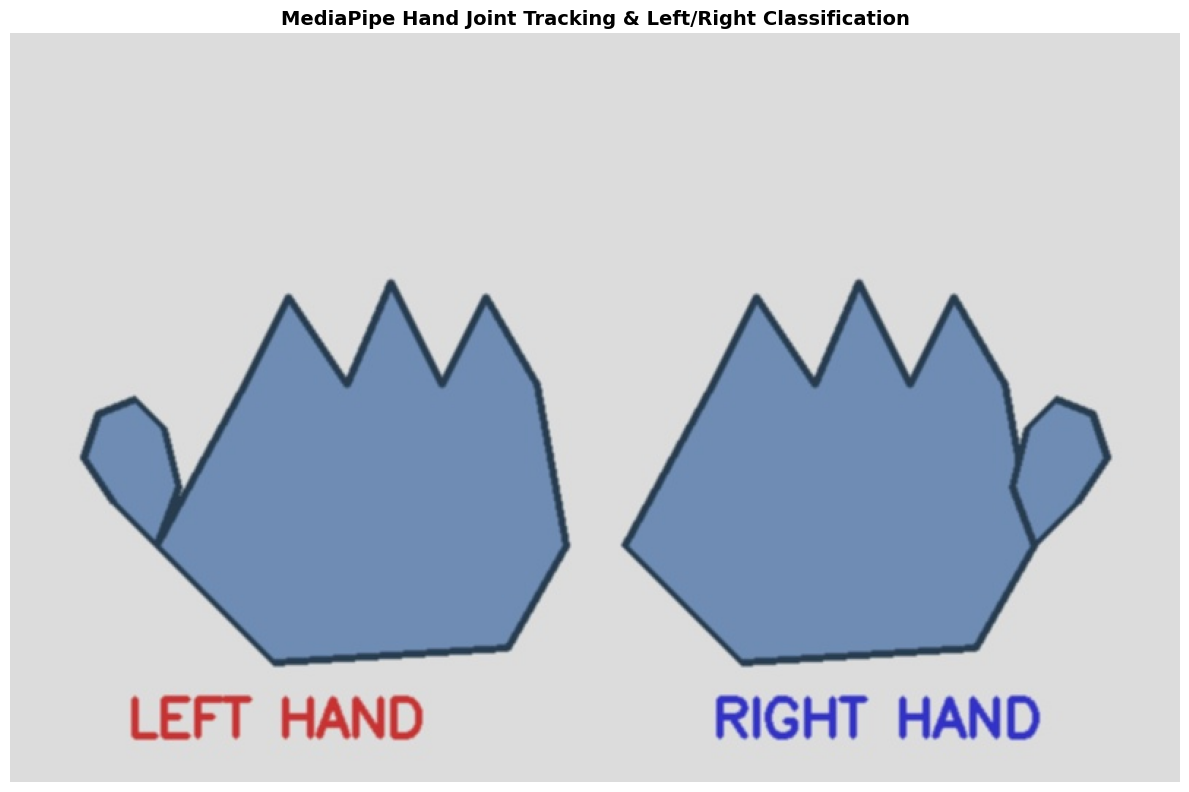

In [3]:
# --- Load hands image ---
image_path = 'hands_test.jpg'
abs_image_path = os.path.abspath(image_path)

if not os.path.exists(image_path):
    raise FileNotFoundError(f"Image not found: {abs_image_path}. Please run Cell 2 first.")

file_size = os.path.getsize(image_path)
print(f"Loading {abs_image_path} ({file_size:,} bytes)...")

img_cv = cv2.imread(image_path)
if img_cv is None:
    raise ValueError(
        f"OpenCV could not read {abs_image_path} (size={file_size} bytes). "
        "Please delete the file and re-run Cell 2 to re-download or regenerate it."
    )

img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
print(f"Image loaded successfully. Shape: {img_cv.shape}")

# --- Configure Hand Landmarker ---
options = vision.HandLandmarkerOptions(
    base_options=python.BaseOptions(model_asset_path='hand_landmarker.task'),
    num_hands=2
)

# --- Run detection ---
print("Running hand detection...")
with vision.HandLandmarker.create_from_options(options) as landmarker:
    detection_result = landmarker.detect(mp_image)
print("Hand detection complete.")

# --- Draw results ---
annotated_image = img_rgb.copy()
h, w, _ = annotated_image.shape

# Full hand skeleton connections (all 21-point connections)
HAND_CONNECTIONS = [
    # Thumb
    (0, 1), (1, 2), (2, 3), (3, 4),
    # Index finger
    (0, 5), (5, 6), (6, 7), (7, 8),
    # Middle finger
    (0, 9), (9, 10), (10, 11), (11, 12),
    # Ring finger
    (0, 13), (13, 14), (14, 15), (15, 16),
    # Pinky
    (0, 17), (17, 18), (18, 19), (19, 20),
    # Palm knuckle bar
    (5, 9), (9, 13), (13, 17)
]

if detection_result.hand_landmarks:
    print(f"\nDetected {len(detection_result.hand_landmarks)} hand(s):")
    for idx, hand_landmarks in enumerate(detection_result.hand_landmarks):
        handedness = detection_result.handedness[idx][0]
        hand_label = handedness.category_name
        confidence = handedness.score
        print(f"  Hand #{idx+1}: {hand_label} (confidence={confidence:.2f})")

        # Color code: blue for Left, red for Right
        line_color = (255, 80, 0) if hand_label == 'Left' else (0, 80, 255)
        dot_color = (0, 220, 100) if hand_label == 'Left' else (220, 100, 0)

        # Draw skeleton lines
        for (si, ei) in HAND_CONNECTIONS:
            pt1 = hand_landmarks[si]
            pt2 = hand_landmarks[ei]
            x1, y1 = int(pt1.x * w), int(pt1.y * h)
            x2, y2 = int(pt2.x * w), int(pt2.y * h)
            cv2.line(annotated_image, (x1, y1), (x2, y2), line_color, 4, lineType=cv2.LINE_AA)

        # Draw joint nodes
        for lm in hand_landmarks:
            cx, cy = int(lm.x * w), int(lm.y * h)
            cv2.circle(annotated_image, (cx, cy), 8, dot_color, -1, lineType=cv2.LINE_AA)
            cv2.circle(annotated_image, (cx, cy), 8, (255, 255, 255), 2, lineType=cv2.LINE_AA)  # white border

        # Label near wrist (landmark 0)
        wrist = hand_landmarks[0]
        wx, wy = int(wrist.x * w), int(wrist.y * h)
        label_color = (50, 50, 255) if hand_label == 'Left' else (255, 50, 50)
        cv2.putText(
            annotated_image,
            f"{hand_label} ({confidence:.2f})",
            (max(0, wx - 80), min(h - 10, wy + 60)),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.4, label_color, 4, cv2.LINE_AA
        )
else:
    print("No hands detected in this image.")
    print("Note: MediaPipe works best on real hand photos. The synthetic image may not produce detections.")

# --- Display ---
plt.figure(figsize=(12, 9))
plt.imshow(annotated_image)
plt.title("MediaPipe Hand Joint Tracking & Left/Right Classification", fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Face Mesh Landmark Tracking

Next, we initialize the `FaceLandmarker` task, process the face test image, and draw the mesh landmarks to visualize facial geometry (468+ landmark points).

Loading c:\Users\xinod\Documents\Projects\CEC616\scripts\CA\face_test.jpg (1,276,121 bytes)...
Face image loaded. Shape: (3356, 2687, 3)
Running face mesh detection...
Face detection complete.
Detected 1 face(s), 478 total landmarks.


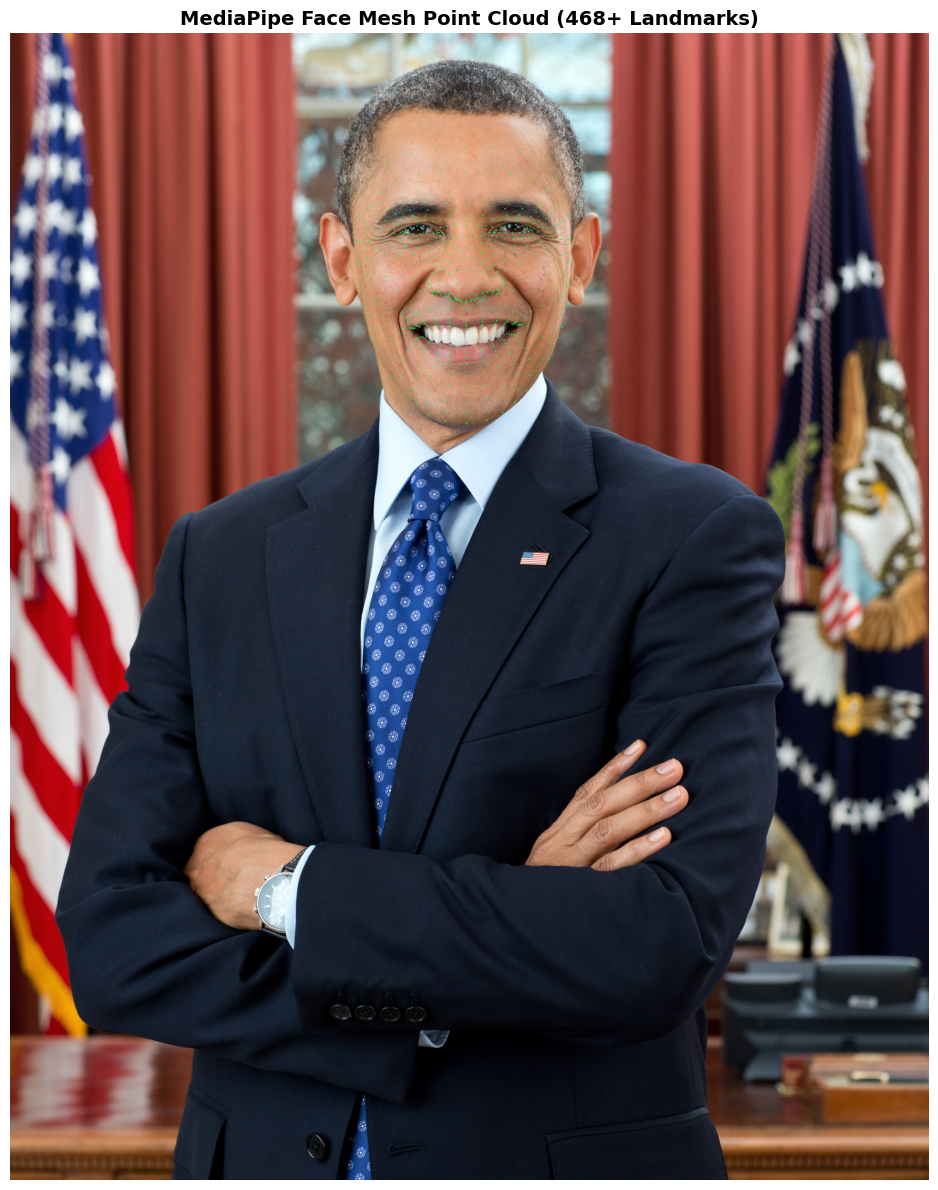

In [4]:
# --- Load face image ---
face_image_path = 'face_test.jpg'
abs_face_path = os.path.abspath(face_image_path)

if not os.path.exists(face_image_path):
    raise FileNotFoundError(f"Face image not found: {abs_face_path}. Please run Cell 2 first.")

face_file_size = os.path.getsize(face_image_path)
print(f"Loading {abs_face_path} ({face_file_size:,} bytes)...")

face_cv = cv2.imread(face_image_path)
if face_cv is None:
    raise ValueError(
        f"OpenCV could not read {abs_face_path} (size={face_file_size} bytes). "
        "Please delete the file and re-run Cell 2."
    )

face_rgb = cv2.cvtColor(face_cv, cv2.COLOR_BGR2RGB)
mp_face_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=face_rgb)
print(f"Face image loaded. Shape: {face_cv.shape}")

# --- Configure Face Landmarker ---
face_options = vision.FaceLandmarkerOptions(
    base_options=python.BaseOptions(model_asset_path='face_landmarker.task'),
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
    num_faces=1
)

# --- Run detection ---
print("Running face mesh detection...")
with vision.FaceLandmarker.create_from_options(face_options) as landmarker:
    face_result = landmarker.detect(mp_face_image)
print("Face detection complete.")

# --- Draw landmarks ---
annotated_face = face_rgb.copy()
fh, fw, _ = annotated_face.shape

if face_result.face_landmarks:
    total_landmarks = sum(len(fl) for fl in face_result.face_landmarks)
    print(f"Detected {len(face_result.face_landmarks)} face(s), {total_landmarks} total landmarks.")

    for face_landmarks in face_result.face_landmarks:
        for lm in face_landmarks:
            x = int(lm.x * fw)
            y = int(lm.y * fh)
            cv2.circle(annotated_face, (x, y), 2, (0, 255, 100), -1)
else:
    print("No face detected in this image.")

# --- Display ---
plt.figure(figsize=(10, 12))
plt.imshow(annotated_face)
plt.title("MediaPipe Face Mesh Point Cloud (468+ Landmarks)", fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()